## EDA categorical features

In this notebook I will perform EDA on categorical features.

#### Columns:
- `gender`
- `partner`
- `dependents`
- `phone_service`
- `multiple_lines`
- `internet_service`
- `online_security`
- `online_backup`
- `device_protection`
- `tech_support`
- `streaming_tv`
- `streaming_movies`
- `contract`
- `paperless_billing`
- `payment_method`
- `senior_citizen`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from telco_churn.config import (
    CATEGORICAL_COLUMNS,
    TARGET_COLUMN,
    BINARY_COLUMN,
)
from telco_churn.paths import (
    TELCO_CUSTOMERS_TRAIN_PATH,
    EDA_CATEGORICAL_DIR,
)
from telco_churn.plots import (
    add_bar_labels,
    save_plot,
)

## Helpers

In [2]:
# Encode churn as a numerical variable
def encode_churn(df, target_column):
    churn_map = {
        'No': 0,
        'Yes': 1,
    }

    return df[target_column].map(churn_map)


# Calculate customer count and churn rate by category
def churn_rate_summary(df, column, target_column, baseline_rate):
    result = (
        df.groupby(column)[target_column]
            .agg(
                customers='count',
                churn_rate='mean',
            )
    ).reset_index()
    result['churn_rate'] = (result['churn_rate'] * 100).round(2)
    result['diff_from_churn_rate_baseline'] = (result['churn_rate'] - baseline_rate).round(2)

    return result

    
# Generate bar plot with default setup and save it to a eda categorical folder
def churn_rate_bar_plot(df, x, churn_rate_baseline, ylim):
    column_label = x.replace('_', ' ').capitalize()
    
    ax = df.plot(
        kind='bar',
        x=x,
        y='churn_rate',
        figsize=(5, 4),
        rot=0,
        width=0.9,
    )
    add_bar_labels(axes=ax)
    ax.axhline(
        y=churn_rate_baseline,
        color='grey',
        linestyle='--',
        label='Churn rate baseline',
    )
    ax.set_title(f'{column_label} churn rate')
    ax.set_xlabel(column_label)
    ax.set_ylabel('Churn rate (%)')
    ax.set_ylim(0, ylim)
    ax.legend()
    plt.tight_layout()
    save_plot(
        path=EDA_CATEGORICAL_DIR,
        file_name=f'{x}_churn_rate',
    )
    plt.show()

## Load training data and prepare categorical features for EDA

In [3]:
df_train = pd.read_csv(TELCO_CUSTOMERS_TRAIN_PATH)

df_categorical = df_train[list(CATEGORICAL_COLUMNS)].copy()
df_categorical[BINARY_COLUMN] = df_train[BINARY_COLUMN]
df_categorical[TARGET_COLUMN] = df_train[TARGET_COLUMN]
df_categorical[TARGET_COLUMN] = encode_churn(
    df=df_categorical,
    target_column=TARGET_COLUMN,
)
df_categorical.head(3)

,gender,partner,dependents,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,senior_citizen,churn
0,Female,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Bank transfer (automatic),0,0
1,Male,No,No,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,0,0
2,Male,Yes,Yes,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,0,0


In [4]:
# Calculate churn rate baseline
churn_rate_baseline = (df_categorical[TARGET_COLUMN].mean() * 100).round(2)
churn_rate_baseline

np.float64(26.54)

## Column: `gender`

In [5]:
gender_churn_rate = churn_rate_summary(
    df=df_categorical,
    column='gender',
    target_column=TARGET_COLUMN,
    baseline_rate=churn_rate_baseline,
)
gender_churn_rate

,gender,customers,churn_rate,diff_from_churn_rate_baseline
0,Female,2795,26.58,0.04
1,Male,2839,26.49,-0.05


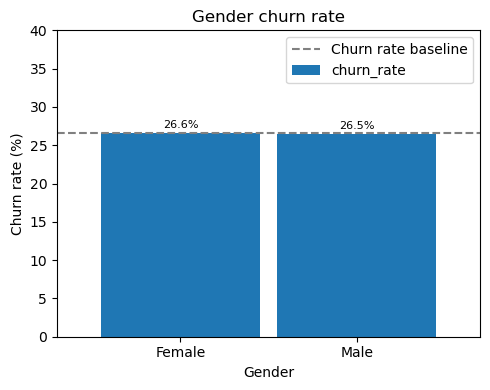

In [6]:
churn_rate_bar_plot(
    df=gender_churn_rate,
    x='gender',
    churn_rate_baseline=churn_rate_baseline,
    ylim=40,
)

## Column: `partner`

In [7]:
partner_churn_rate = churn_rate_summary(
    df=df_categorical,
    column='partner',
    target_column=TARGET_COLUMN,
    baseline_rate=churn_rate_baseline,
)
partner_churn_rate

,partner,customers,churn_rate,diff_from_churn_rate_baseline
0,No,2898,32.51,5.97
1,Yes,2736,20.21,-6.33


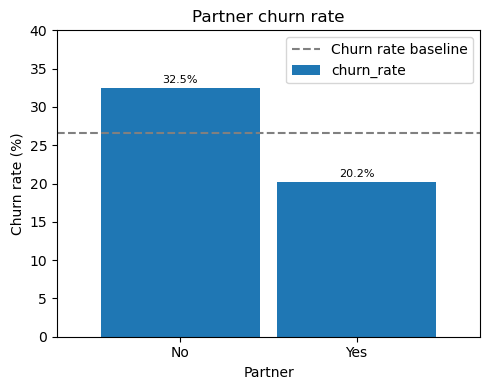

In [8]:
churn_rate_bar_plot(
    df=partner_churn_rate,
    x='partner',
    churn_rate_baseline=churn_rate_baseline,
    ylim=40,
)

## Column: `dependents`

In [9]:
dependents_churn_rate = churn_rate_summary(
    df=df_categorical,
    column='dependents',
    target_column=TARGET_COLUMN,
    baseline_rate=churn_rate_baseline,
)
dependents_churn_rate

,dependents,customers,churn_rate,diff_from_churn_rate_baseline
0,No,3924,31.45,4.91
1,Yes,1710,15.26,-11.28


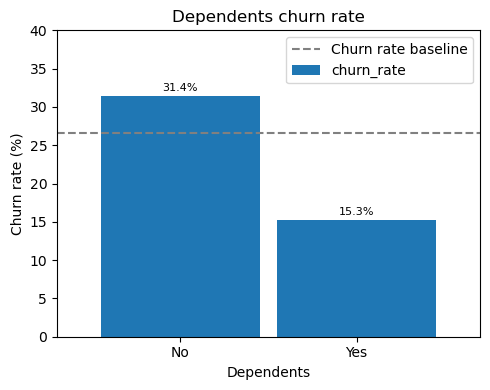

In [10]:
churn_rate_bar_plot(
    df=dependents_churn_rate,
    x='dependents',
    churn_rate_baseline=churn_rate_baseline,
    ylim=40,
)

## Column: `senior_citizen`

In [11]:
senior_citizen_churn_rate = churn_rate_summary(
    df=df_categorical,
    column='senior_citizen',
    target_column=TARGET_COLUMN,
    baseline_rate=churn_rate_baseline,
)
senior_citizen_churn_rate

,senior_citizen,customers,churn_rate,diff_from_churn_rate_baseline
0,0,4695,23.64,-2.90
1,1,939,41.00,14.46


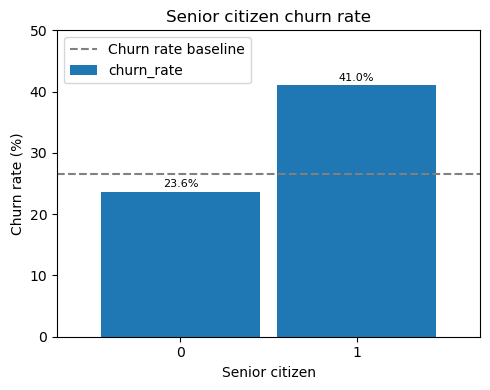

In [12]:
churn_rate_bar_plot(
    df=senior_citizen_churn_rate,
    x='senior_citizen',
    churn_rate_baseline=churn_rate_baseline,
    ylim=50,
)

## Column: `phone_service`

In [13]:
phone_service_churn_rate = churn_rate_summary(
    df=df_categorical,
    column='phone_service',
    target_column=TARGET_COLUMN,
    baseline_rate=churn_rate_baseline,
)
phone_service_churn_rate

,phone_service,customers,churn_rate,diff_from_churn_rate_baseline
0,No,547,25.96,-0.58
1,Yes,5087,26.60,0.06


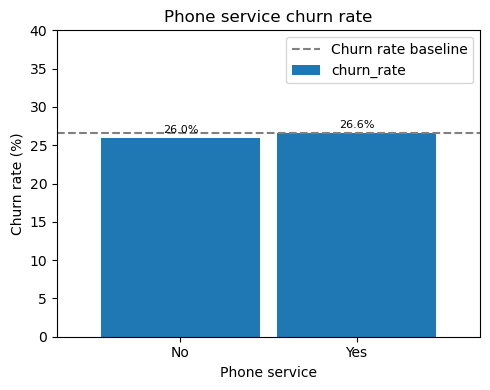

In [14]:
churn_rate_bar_plot(
    df=phone_service_churn_rate,
    x='phone_service',
    churn_rate_baseline=churn_rate_baseline,
    ylim=40,
)

## Column: `multiple_lines`

In [15]:
multiple_lines_churn_rate = churn_rate_summary(
    df=df_categorical,
    column='multiple_lines',
    target_column=TARGET_COLUMN,
    baseline_rate=churn_rate_baseline,
)
multiple_lines_churn_rate

,multiple_lines,customers,churn_rate,diff_from_churn_rate_baseline
0,No,2697,25.18,-1.36
1,No phone service,547,25.96,-0.58
2,Yes,2390,28.20,1.66


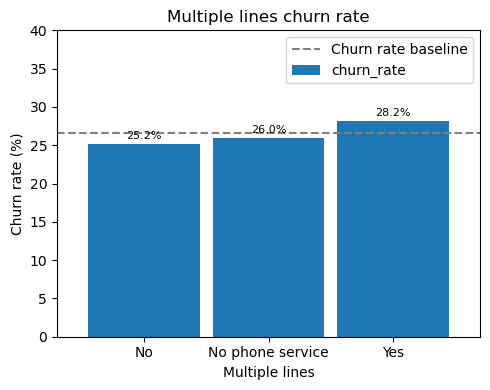

In [16]:
churn_rate_bar_plot(
    df=multiple_lines_churn_rate,
    x='multiple_lines',
    churn_rate_baseline=churn_rate_baseline,
    ylim=40,
)

## Column: `internet_service`

In [17]:
internet_service_churn_rate = churn_rate_summary(
    df=df_categorical,
    column='internet_service',
    target_column=TARGET_COLUMN,
    baseline_rate=churn_rate_baseline,
)
internet_service_churn_rate

,internet_service,customers,churn_rate,diff_from_churn_rate_baseline
0,DSL,1910,19.11,-7.43
1,Fiber optic,2508,41.51,14.97
2,No,1216,7.32,-19.22


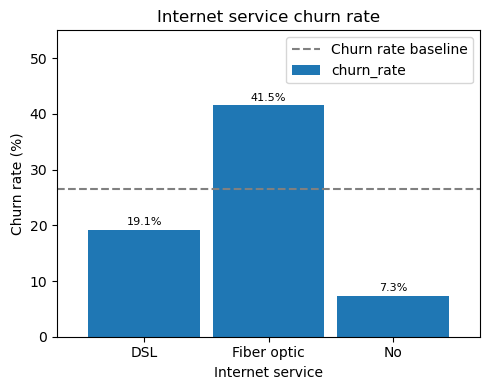

In [18]:
churn_rate_bar_plot(
    df=internet_service_churn_rate,
    x='internet_service',
    churn_rate_baseline=churn_rate_baseline,
    ylim=55,
)

## Column: `online_security`

In [19]:
online_security_churn_rate = churn_rate_summary(
    df=df_categorical,
    column='online_security',
    target_column=TARGET_COLUMN,
    baseline_rate=churn_rate_baseline,
)
online_security_churn_rate

,online_security,customers,churn_rate,diff_from_churn_rate_baseline
0,No,2814,41.90,15.36
1,No internet service,1216,7.32,-19.22
2,Yes,1604,14.15,-12.39


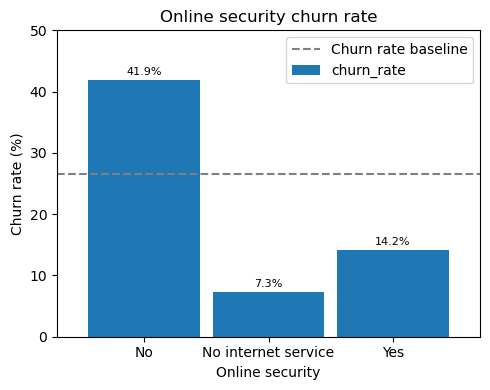

In [20]:
churn_rate_bar_plot(
    df=online_security_churn_rate,
    x='online_security',
    churn_rate_baseline=churn_rate_baseline,
    ylim=50,
)

## Column: `online_backup`

In [21]:
online_backup_churn_rate = churn_rate_summary(
	df=df_categorical,
	column='online_backup',
	target_column=TARGET_COLUMN,
	baseline_rate=churn_rate_baseline,
)
online_backup_churn_rate

,online_backup,customers,churn_rate,diff_from_churn_rate_baseline
0,No,2463,40.11,13.57
1,No internet service,1216,7.32,-19.22
2,Yes,1955,21.38,-5.16


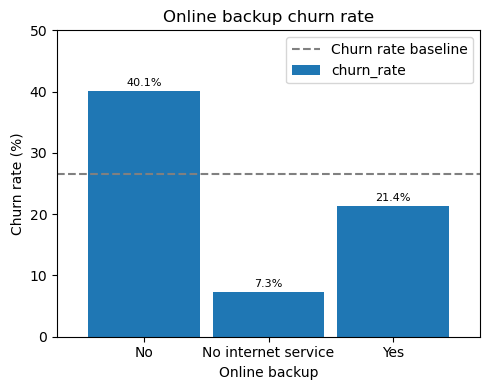

In [22]:
churn_rate_bar_plot(
	df=online_backup_churn_rate,
	x='online_backup',
	churn_rate_baseline=churn_rate_baseline,
	ylim=50,
)

## Column: `device_protection`

In [23]:
device_protection_churn_rate = churn_rate_summary(
	df=df_categorical,
	column='device_protection',
	target_column=TARGET_COLUMN,
	baseline_rate=churn_rate_baseline,
)
device_protection_churn_rate

,device_protection,customers,churn_rate,diff_from_churn_rate_baseline
0,No,2471,38.69,12.15
1,No internet service,1216,7.32,-19.22
2,Yes,1947,23.11,-3.43


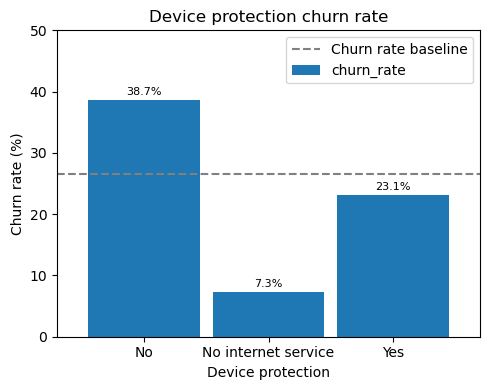

In [24]:
churn_rate_bar_plot(
	df=device_protection_churn_rate,
	x='device_protection',
	churn_rate_baseline=churn_rate_baseline,
	ylim=50,
)

## Column: `tech_support`

In [25]:
tech_support_churn_rate = churn_rate_summary(
	df=df_categorical,
	column='tech_support',
	target_column=TARGET_COLUMN,
	baseline_rate=churn_rate_baseline,
)
tech_support_churn_rate

,tech_support,customers,churn_rate,diff_from_churn_rate_baseline
0,No,2780,41.65,15.11
1,No internet service,1216,7.32,-19.22
2,Yes,1638,15.14,-11.40


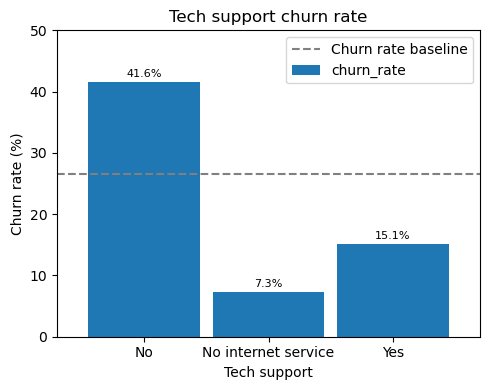

In [26]:
churn_rate_bar_plot(
	df=tech_support_churn_rate,
	x='tech_support',
	churn_rate_baseline=churn_rate_baseline,
	ylim=50,
)

## Column: `streaming_tv`

In [27]:
streaming_tv_churn_rate = churn_rate_summary(
	df=df_categorical,
	column='streaming_tv',
	target_column=TARGET_COLUMN,
	baseline_rate=churn_rate_baseline,
)
streaming_tv_churn_rate

,streaming_tv,customers,churn_rate,diff_from_churn_rate_baseline
0,No,2239,33.50,6.96
1,No internet service,1216,7.32,-19.22
2,Yes,2179,30.11,3.57


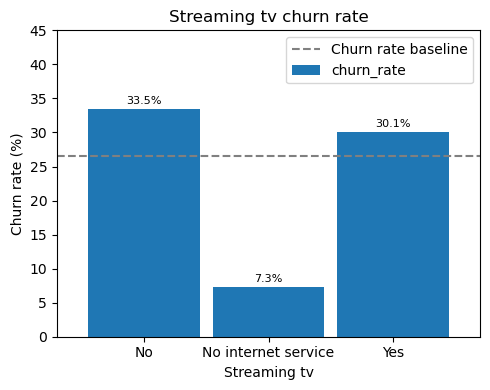

In [28]:
churn_rate_bar_plot(
	df=streaming_tv_churn_rate,
	x='streaming_tv',
	churn_rate_baseline=churn_rate_baseline,
	ylim=45,
)

## Column: `streaming_movies`

In [29]:
streaming_movies_churn_rate = churn_rate_summary(
	df=df_categorical,
	column='streaming_movies',
	target_column=TARGET_COLUMN,
	baseline_rate=churn_rate_baseline,
)
streaming_movies_churn_rate

,streaming_movies,customers,churn_rate,diff_from_churn_rate_baseline
0,No,2211,33.74,7.20
1,No internet service,1216,7.32,-19.22
2,Yes,2207,29.90,3.36


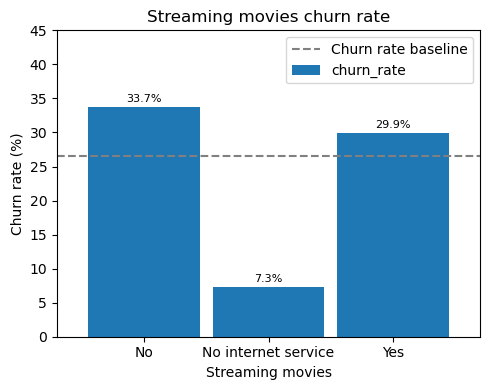

In [30]:
churn_rate_bar_plot(
	df=streaming_movies_churn_rate,
	x='streaming_movies',
	churn_rate_baseline=churn_rate_baseline,
	ylim=45,
)

## Column: `contract`

In [31]:
contract_churn_rate = churn_rate_summary(
	df=df_categorical,
	column='contract',
	target_column=TARGET_COLUMN,
	baseline_rate=churn_rate_baseline,
)
contract_churn_rate

,contract,customers,churn_rate,diff_from_churn_rate_baseline
0,Month-to-month,3096,42.89,16.35
1,One year,1167,10.97,-15.57
2,Two year,1371,2.84,-23.70


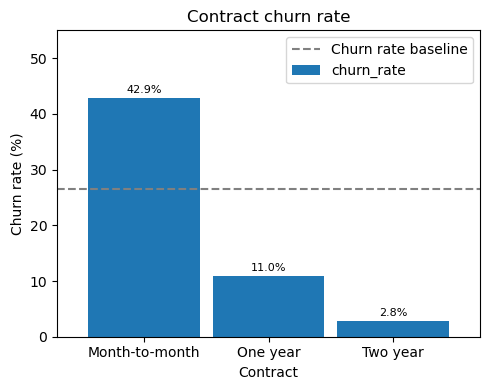

In [32]:
churn_rate_bar_plot(
	df=contract_churn_rate,
	x='contract',
	churn_rate_baseline=churn_rate_baseline,
	ylim=55,
)

## Column: `paperless_billing`

In [33]:
paperless_billing_churn_rate = churn_rate_summary(
	df=df_categorical,
	column='paperless_billing',
	target_column=TARGET_COLUMN,
	baseline_rate=churn_rate_baseline,
)
paperless_billing_churn_rate

,paperless_billing,customers,churn_rate,diff_from_churn_rate_baseline
0,No,2275,16.57,-9.97
1,Yes,3359,33.28,6.74


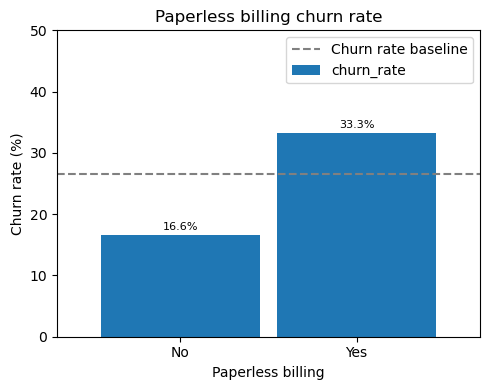

In [34]:
churn_rate_bar_plot(
	df=paperless_billing_churn_rate,
	x='paperless_billing',
	churn_rate_baseline=churn_rate_baseline,
	ylim=50,
)

## Column: `payment_method`

In [35]:
payment_method_churn_rate = churn_rate_summary(
	df=df_categorical,
	column='payment_method',
	target_column=TARGET_COLUMN,
	baseline_rate=churn_rate_baseline,
)
payment_method_churn_rate

,payment_method,customers,churn_rate,diff_from_churn_rate_baseline
0,Bank transfer (automatic),1246,15.89,-10.65
1,Credit card (automatic),1217,14.38,-12.16
2,Electronic check,1908,45.86,19.32
3,Mailed check,1263,19.56,-6.98


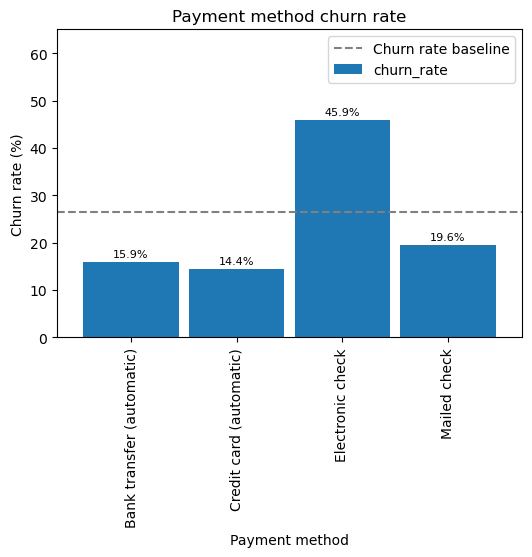

In [36]:
payment_method_ax = payment_method_churn_rate.plot(
    kind='bar',
    x='payment_method',
    y='churn_rate',
    figsize=(6, 4),
    rot=90,
    width=0.9,
)
add_bar_labels(axes=payment_method_ax)
payment_method_ax.axhline(
    y=churn_rate_baseline,
    color='grey',
    linestyle='--',
    label='Churn rate baseline',
)
payment_method_ax.set_title('Payment method churn rate')
payment_method_ax.set_xlabel('Payment method')
payment_method_ax.set_ylabel('Churn rate (%)')
payment_method_ax.set_ylim(0, 65)
payment_method_ax.legend()
save_plot(
    path=EDA_CATEGORICAL_DIR,
    file_name='payment_method_churn_rate'
)
plt.show()

## Summary

Several customer segments have a churn rate at least 10 percentage points above the baseline, including:

- customers using electronic check as a payment method: +19.32 pp
- customers with a month-to-month contract: +16.35 pp
- customers without online security: +15.36 pp
- customers without tech support: +15.11 pp
- customers with fiber optic internet service: +14.97 pp
- senior citizens: +14.46 pp
- customers without online backup: +13.57 pp
- customers without device protection: +12.15 pp

Several other segments also have churn rates above the baseline, but by less than 10 percentage points:

- customers without streaming movies: +7.20 pp
- customers without streaming TV: +6.96 pp
- customers using paperless billing: +6.74 pp
- customers without a partner: +5.97 pp
- customers without dependents: +4.91 pp